In [1]:
#Descriptive Stats for BOA

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("D:\Shukra_sir\WQI_Research\Scripts and Data\StatisticsAnalysis\Mean\DOC_BOA_SR_DescStats.csv")
df.shape

(9, 13)

In [10]:
df.set_index(df.columns[0], inplace=True)

# Clean index text
df.index = df.index.str.strip()

print(df.index)

Index(['mean', 'min', 'max', 'Q1_25%', 'Median_Q2_50%', 'Q3_75%',
       'Std_Deviation', 'Coeff_of_Variation', 'length'],
      dtype='str', name='Unnamed: 0')


In [11]:
bands = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12']
print(bands)

['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12']


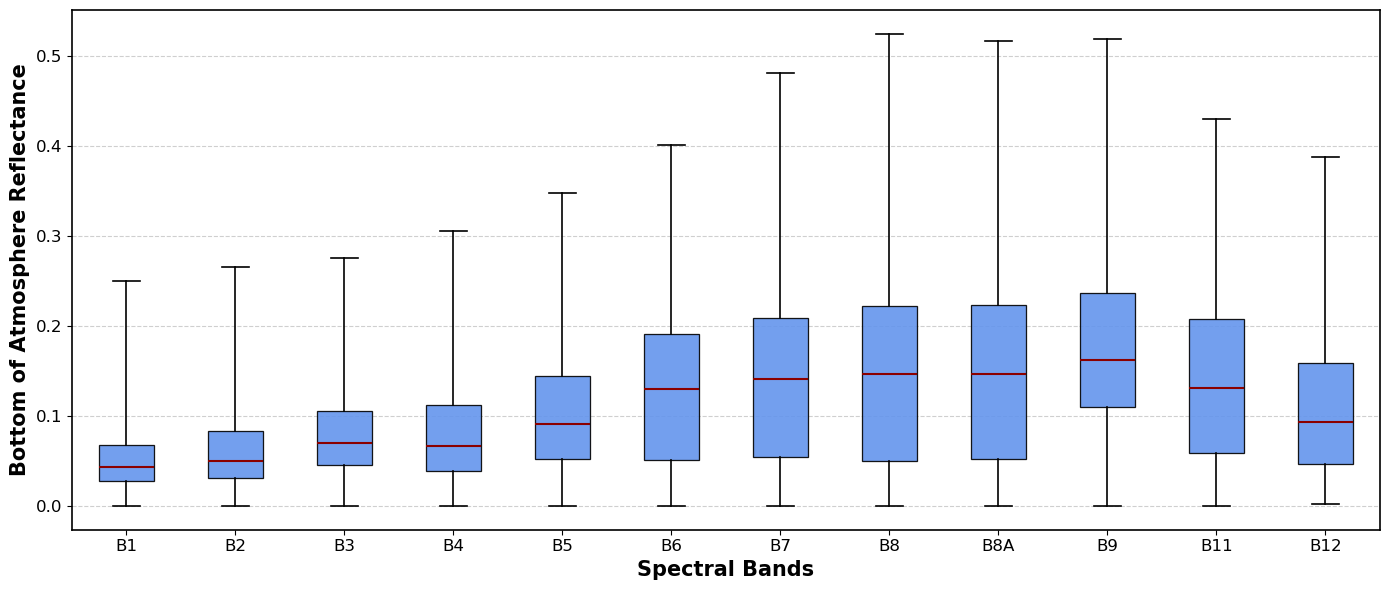

In [23]:
box_data = []

for band in bands:
    stats = {
        'label': band,
        'whislo': df.loc['min', band],
        'q1': df.loc['Q1_25%', band],
        'med': df.loc['Median_Q2_50%', band],
        'q3': df.loc['Q3_75%', band],
        'whishi': df.loc['max', band],
        'fliers': []
    }
    box_data.append(stats)


# -------------------------
# Create Figure
# -------------------------
fig, ax = plt.subplots(figsize=(14,6))

box = ax.bxp(
    box_data,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="#6495ED", alpha = 0.9 ,edgecolor="black", linewidth=0.93),
    medianprops=dict(color="#8B0000", linewidth=1.5),
    whiskerprops=dict(color="black", linewidth=1.2),
    capprops=dict(color="black", linewidth=1.2)
)

# -------------------------
# Axis Styling
# -------------------------
ax.set_xlabel("Spectral Bands", fontsize=15, fontweight='bold')
ax.set_ylabel("Bottom of Atmosphere Reflectance", fontsize=15, fontweight='bold')
#ax.set_title("Distribution of Spectral Bands (B1–B12)", fontsize=18, fontweight='bold')

ax.tick_params(axis='both', labelsize=12)

# Light horizontal grid only
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.xaxis.grid(False)

# Thicker border
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()